<center>

</center>
<div style="padding:20px;color:#150d0a;margin:10px;font-size:220%;text-align:center;display:fill;border-radius:20px;border-width: 5px;border-style: solid;border-color: #150d0a;background-color:#eca912;overflow:hidden;font-weight:500">DR Detection utilizing Deep Learning Models and XAI methods</div>

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import regularizers


In [3]:
data_dir = r"Data_large/train"
classes_list = os.listdir(data_dir)

train_dir = "Data_large/train"
val_dir = "Data_large/val"

In [4]:
img_height, img_width = 320, 320
batch_size = 32
num_classes = 5

train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v3.preprocess_input,
    rotation_range=15,            
    width_shift_range=0.1,          
    height_shift_range=0.1,         
    shear_range=0.1,              
    zoom_range=0.2,               
    horizontal_flip=True,
    brightness_range=(0.9, 1.1),    
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v3.preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle = False
)

Found 5150 images belonging to 5 classes.
Found 1254 images belonging to 5 classes.


In [57]:
def plot_confusion_matrix(y_true, y_pred, classes,
                          normalize=False,
                          title=None,
                          cmap=plt.cm.Blues):
    if not title:
        title = 'Normalized Confusion Matrix' if normalize else 'Confusion Matrix, without Normalization'
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print("Confusion matrix, without normalization")
    print(cm)
    
    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=classes,
           yticklabels=classes,
           title=title,
           ylabel='True label',
           xlabel='Predicted label')
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    return ax


In [58]:
base_model = tf.keras.applications.MobileNetV3Large(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False 

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.2),  
    Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])


In [59]:
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05)

optimizer_initial = Adam(learning_rate=1e-3)
model.compile(optimizer=optimizer_initial,
              loss=loss_fn,
              metrics=["accuracy", tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

callbacks_initial = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, verbose=1),
    ModelCheckpoint("mobilenetv3_best_initial.keras", monitor='val_accuracy', save_best_only=True, verbose=1)
]

initial_epochs = 10
history_initial = model.fit(
    train_generator,
    epochs=initial_epochs,
    validation_data=val_generator,
    callbacks=callbacks_initial,
    verbose=1
)


fine_tune_at = len(base_model.layers) - 50
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

optimizer_fine = Adam(learning_rate=1e-4)   
model.compile(optimizer=optimizer_fine,
              loss=loss_fn,
              metrics=["accuracy", tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

callbacks_fine = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, verbose=1),
    ModelCheckpoint("mobilenetv3_best_fine.keras", monitor='val_accuracy', save_best_only=True, verbose=1)
]

fine_tune_epochs = 20
history_fine = model.fit(
    train_generator,
    epochs=fine_tune_epochs,
    validation_data=val_generator,
    callbacks=callbacks_fine,
    verbose=1
)

val_loss, val_acc, val_precision, val_recall = model.evaluate(val_generator, verbose=1)
print(f"\nValidation Accuracy: {val_acc * 100:.2f}%")
print(f"Validation Precision: {val_precision * 100:.2f}%")
print(f"Validation Recall: {val_recall * 100:.2f}%")

Epoch 1/10
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 825ms/step - accuracy: 0.3763 - loss: 2.1840 - precision_22: 0.4276 - recall_22: 0.2772
Epoch 1: val_accuracy improved from -inf to 0.52995, saving model to mobilenetv3_best_initial.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.3788 - loss: 2.1765 - precision_22: 0.4308 - recall_22: 0.2800 - val_accuracy: 0.5300 - val_loss: 1.6248 - val_precision_22: 0.6336 - val_recall_22: 0.3825 - learning_rate: 0.0010
Epoch 2/10
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 653ms/step - accuracy: 0.5083 - loss: 1.7796 - precision_22: 0.5980 - recall_22: 0.4056
Epoch 2: val_accuracy improved from 0.52995 to 0.56682, saving model to mobilenetv3_best_initial.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 28s 706ms/step - accuracy: 0.5089 - loss: 1.7767 - precision_22: 0.5985 - recall_22: 0.4060 - val_accuracy: 0.5668 - val_loss: 1.4777 - val_precision_22: 0.6718 - val_recall_22: 0.4055 - learning_rate: 0.0010
Epoch 3/10
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 661ms/step - accuracy: 0.5586

14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 355ms/step
Normalized confusion matrix
[[0.87179487 0.         0.02564103 0.1025641  0.        ]
 [0.30232558 0.58139535 0.02325581 0.06976744 0.02325581]
 [0.08333333 0.         0.91666667 0.         0.        ]
 [0.08888889 0.08888889 0.         0.8        0.02222222]
 [0.14285714 0.11904762 0.         0.21428571 0.52380952]]


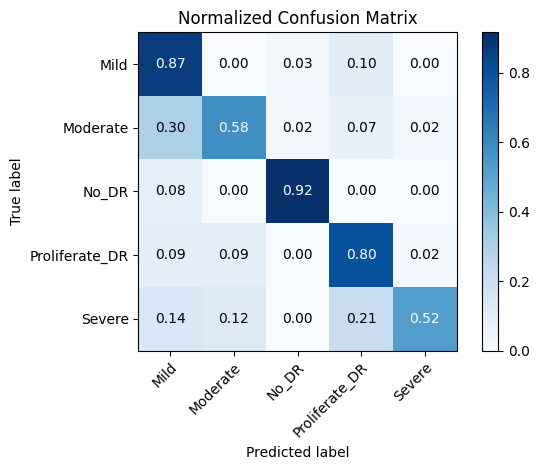

In [60]:
val_preds = model.predict(val_generator)
val_pred_classes = np.argmax(val_preds, axis=1)
true_classes = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

plot_confusion_matrix(true_classes, val_pred_classes, classes=class_labels, normalize=True)
plt.show()

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step
Accuracy: 74.19%
Precision (macro): 77.16%
Recall (macro): 73.87%
F1-Score (macro): 73.49%
Specificity (macro): 93.61%
AUC-ROC: 0.9232
Confusion matrix, without normalization
[[68  0  2  8  0]
 [26 50  2  6  2]
 [ 8  0 88  0  0]
 [ 8  8  0 72  2]
 [12 10  0 18 44]]
Normalized confusion matrix
[[0.87179487 0.         0.02564103 0.1025641  0.        ]
 [0.30232558 0.58139535 0.02325581 0.06976744 0.02325581]
 [0.08333333 0.         0.91666667 0.         0.        ]
 [0.08888889 0.08888889 0.         0.8        0.02222222]
 [0.14285714 0.11904762 0.         0.21428571 0.52380952]]


<Axes: title={'center': 'Normalized Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>

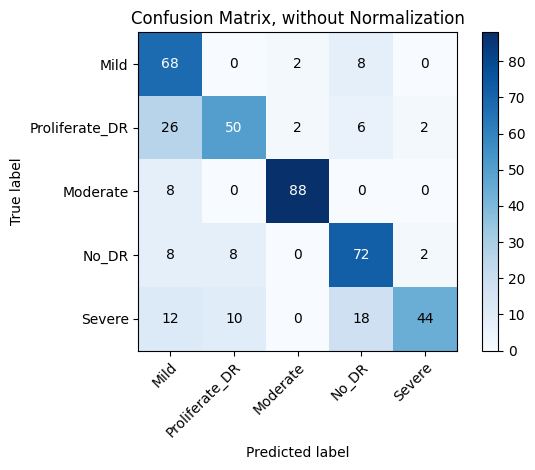

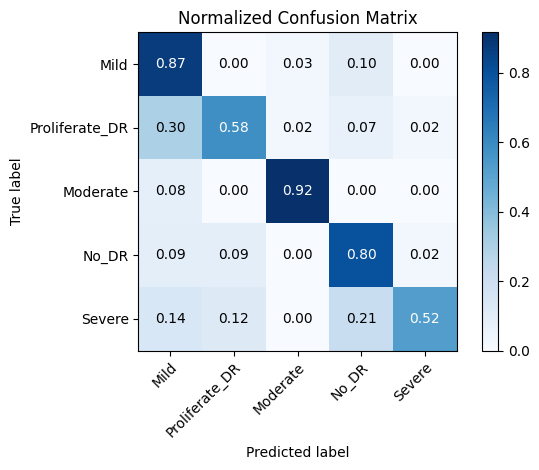

In [61]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

y_true = val_generator.classes

y_pred_prob = model.predict(val_generator)

y_pred = np.argmax(y_pred_prob, axis=1)

accuracy = accuracy_score(y_true, y_pred)

cr = classification_report(y_true, y_pred, target_names=classes_list, output_dict=True)

precision_macro = cr['macro avg']['precision']
recall_macro = cr['macro avg']['recall']
f1_macro = cr['macro avg']['f1-score']

cm = confusion_matrix(y_true, y_pred)

specificity = []
for i in range(num_classes):
    tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])  
    fp = cm[:, i].sum() - cm[i, i]                                
    specificity.append(tn / (tn + fp))

specificity_macro = np.mean(specificity)

auc_roc = roc_auc_score(y_true, y_pred_prob, multi_class='ovr')

# Print all metrics
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision (macro): {precision_macro * 100:.2f}%")
print(f"Recall (macro): {recall_macro * 100:.2f}%")
print(f"F1-Score (macro): {f1_macro * 100:.2f}%")
print(f"Specificity (macro): {specificity_macro * 100:.2f}%")
print(f"AUC-ROC: {auc_roc:.4f}")

plot_confusion_matrix(y_true, y_pred, classes_list, normalize=False)
plot_confusion_matrix(y_true, y_pred, classes_list, normalize=True)